# 1.3 Evaluación de calidad

**Actividad 1.3**
- Construye un registro de problemas de calidad: problema, evidencia cuantificada, impacto potencial y tratamiento decidido (corregir, excluir, marcar o aceptar).

**Contenido**: cada sección revisa un tipo de problema y lo agrega al registro.

| Sección | Categoría | Pregunta que responde |
|---|---|---|
| **1.3.a** | Faltantes | ¿Falta información? |
| **1.3.b** | Duplicados | ¿Se cuenta algo más de una vez? |
| **1.3.c** | Formato | ¿Lo mismo está escrito de formas distintas? |
| **1.3.d** | Catálogo | ¿La base y los catálogos se reconocen entre sí? |
| **1.3.e** | Valores | ¿Los números significan lo que parecen? |
| **1.3.f** | — | Registro de calidad completo |

| Artefacto | Ruta |
|---|---|
| Entrada | `0_datos/KPIS_historico.xlsx` |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 80)

ARCHIVO = Path("../../0_datos/KPIS_historico.xlsx")
VERDE, AMARILLO, NARANJA, ROJO, AZUL, MORADO, ROSADO, GRIS = (
    "#00c389", "#fdda24", "#ff7f41", "#e03c31", "#59cbe8", "#9063cd", "#f5b6cd", "#9e9a99")

kpis = pd.read_excel(ARCHIVO, sheet_name="query", dtype={"Corte": str, "Codigo_EQU": str, "EQU": str})
cat_indicadores = pd.read_excel(ARCHIVO, sheet_name="catalogo_indicadores", dtype=str)
cat_entornos = pd.read_excel(ARCHIVO, sheet_name="catalogo_entornos", dtype=str)

# Un mismo equipo aparece escrito de varias formas (Equ00074 / EQU00074, EQU0024 / EQU00024): se unifica para contar equipos
kpis["codigo_equipo"] = kpis["Codigo_EQU"].str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)


def simplificar(texto):
    """Minúsculas y sin tildes, para detectar nombres que solo difieren en la escritura."""
    return texto.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")


def limpiar_ejes(ax, lados=("top", "right")):
    ax.spines[list(lados)].set_visible(False)


print("Hojas cargadas:")
for nombre, hoja in [("query", kpis), ("catalogo_indicadores", cat_indicadores), ("catalogo_entornos", cat_entornos)]:
    print(f"  {nombre:<22} {len(hoja):>6} filas")


CATEGORIAS = {"Faltantes": MORADO, "Duplicados": AZUL, "Formato": AMARILLO, "Catálogo": NARANJA, "Valores": ROSADO}
TOTAL = len(kpis)
registro = []


def registrar(categoria, problema, filas, evidencia, impacto, tratamiento):
    registro.append({"categoria": categoria, "problema": problema, "filas_afectadas": int(filas),
                     "evidencia": evidencia, "impacto": impacto, "tratamiento": tratamiento})
    print(f"[{categoria}] {problema}: {evidencia} → {tratamiento}")


def pct(n):
    return f"{n:,} filas ({n / TOTAL:.1%})"


Hojas cargadas:
  query                   15188 filas
  catalogo_indicadores       13 filas
  catalogo_entornos          64 filas


## 1.3.a Faltantes


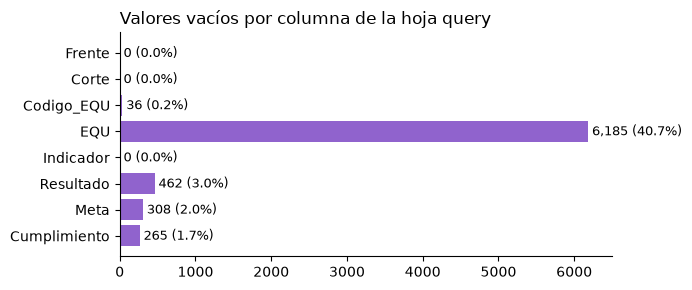

[Faltantes] Filas sin código de equipo: 36 filas (0.2%) → excluir
[Faltantes] Nombre de equipo (EQU) vacío: 6,185 filas (40.7%) → corregir (tomar el nombre del catálogo o de otras filas del mismo código)
[Faltantes] Cumplimiento vacío: 265 filas (1.7%); 59 se pueden recalcular con Resultado y Meta → corregir las recuperables; excluir el resto
[Faltantes] Meses con pocos equipos reportando: 202510: 20 equipos (normal: 64) → marcar (mostrar cuántos equipos hay detrás de cada cifra)


In [2]:
vacios = kpis.drop(columns="codigo_equipo").isna().sum()
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(vacios.index[::-1], vacios.values[::-1], color=[MORADO if v else GRIS for v in vacios.values[::-1]])
for i, v in enumerate(vacios.values[::-1]):
    ax.text(v + 50, i, f"{v:,} ({v / TOTAL:.1%})", va="center", fontsize=9)
ax.set_title("Valores vacíos por columna de la hoja query", loc="left")
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

registrar("Faltantes", "Filas sin código de equipo", vacios["Codigo_EQU"], pct(vacios["Codigo_EQU"]),
          "La medición no se puede asignar a ningún equipo ni entorno.", "excluir")
registrar("Faltantes", "Nombre de equipo (EQU) vacío", vacios["EQU"], pct(vacios["EQU"]),
          "Reportes sin nombre legible; el código sí está.", "corregir (tomar el nombre del catálogo o de otras filas del mismo código)")

sin_cumplimiento = kpis["Cumplimiento"].isna()
recuperable = sin_cumplimiento & kpis["Resultado"].notna() & kpis["Meta"].notna()
registrar("Faltantes", "Cumplimiento vacío", sin_cumplimiento.sum(),
          f"{pct(sin_cumplimiento.sum())}; {recuperable.sum()} se pueden recalcular con Resultado y Meta",
          "Mediciones que no cuentan en el desempeño del equipo.", "corregir las recuperables; excluir el resto")

equipos_mes = kpis.groupby("Corte")["codigo_equipo"].nunique()
bajos = equipos_mes[equipos_mes < equipos_mes.median() / 2]
registrar("Faltantes", "Meses con pocos equipos reportando", kpis["Corte"].isin(bajos.index).sum(),
          ", ".join(f"{m}: {n} equipos" for m, n in bajos.items()) + f" (normal: {equipos_mes.median():.0f})",
          "El promedio del mes representa a pocos equipos.", "marcar (mostrar cuántos equipos hay detrás de cada cifra)")


## 1.3.b Duplicados


In [3]:
repetidas = kpis.duplicated(subset=["Frente", "Corte", "Codigo_EQU", "EQU", "Indicador", "Resultado", "Meta", "Cumplimiento"])
mes_top = kpis.loc[repetidas, "Corte"].value_counts()
registrar("Duplicados", "Filas repetidas exactamente iguales", repetidas.sum(),
          pct(repetidas.sum()) + f"; {mes_top.iloc[0] / repetidas.sum():.0%} están en {mes_top.index[0]}",
          "Cuentan doble a algunos equipos y meses e inflan promedios.", "excluir (se deja una)")

llave = ["Corte", "codigo_equipo", "Indicador"]
unicas = kpis[~repetidas & kpis["codigo_equipo"].notna()]
conflicto = unicas[unicas.duplicated(llave, keep=False)]
encuesta = conflicto[(conflicto["Corte"] == "202502") & conflicto["Indicador"].isin(["Percepción", "Adopción"])]
registrar("Duplicados", "Mismo equipo, indicador y mes con valores distintos", len(conflicto),
          f"{len(conflicto):,} filas; {len(encuesta)} son respuestas individuales de encuesta (Percepción/Adopción 202502)",
          "No hay un único valor oficial del mes y los equipos con más respuestas pesan más.",
          "corregir (promedio por equipo, indicador y mes)")


[Duplicados] Filas repetidas exactamente iguales: 2,182 filas (14.4%); 56% están en 202502 → excluir (se deja una)
[Duplicados] Mismo equipo, indicador y mes con valores distintos: 1,265 filas; 962 son respuestas individuales de encuesta (Percepción/Adopción 202502) → corregir (promedio por equipo, indicador y mes)


## 1.3.c Formato


In [4]:
mal_escrito = kpis["Codigo_EQU"].notna() & (kpis["Codigo_EQU"] != kpis["codigo_equipo"])
registrar("Formato", "Código de equipo mal escrito", mal_escrito.sum(),
          f"{pct(mal_escrito.sum())}; minúsculas o dígitos de menos; {kpis['Codigo_EQU'].nunique()} escrituras para {kpis['codigo_equipo'].nunique()} equipos",
          "Un mismo equipo parece varios equipos distintos.", "corregir (mayúsculas y 5 dígitos)")

frentes = kpis["Frente"].isin(["Talento + Agilidad", "Modeos de trabajo y Agilidad"])
registrar("Formato", "Un frente con tres nombres", frentes.sum(),
          pct(frentes.sum()) + "; Talento + Agilidad (2023-24), Modelos… (2025), Modeos… (2026)",
          "El histórico del frente se ve cortado en tres frentes distintos.",
          "corregir (homologar a 'Modelos de trabajo y Agilidad', también en el catálogo)")


[Formato] Código de equipo mal escrito: 325 filas (2.1%); minúsculas o dígitos de menos; 146 escrituras para 89 equipos → corregir (mayúsculas y 5 dígitos)
[Formato] Un frente con tres nombres: 3,089 filas (20.3%); Talento + Agilidad (2023-24), Modelos… (2025), Modeos… (2026) → corregir (homologar a 'Modelos de trabajo y Agilidad', también en el catálogo)


## 1.3.d Catálogo


In [5]:
fantasma = kpis["codigo_equipo"].notna() & ~kpis["codigo_equipo"].isin(cat_entornos["Codigo_EQU"])
ultimo_mes = kpis[fantasma].groupby("codigo_equipo")["Corte"].max()
registrar("Catálogo", "Equipos fantasma (no están en el catálogo)", fantasma.sum(),
          f"{pct(fantasma.sum())} de {ultimo_mes.size} equipos; {(ultimo_mes >= '202601').sum()} siguen activos en 2026",
          "No se pueden agrupar por entorno.", "marcar como 'Sin entorno' y reportar los activos al dueño del catálogo")

padre = kpis["codigo_equipo"].map(cat_entornos.set_index("Codigo_EQU")["Codigo_Padre"])
no_entorno = padre.notna() & ~padre.str.startswith("ENX", na=False)
registrar("Catálogo", "Equipos con vicepresidencia o sin entorno", no_entorno.sum(),
          f"{pct(no_entorno.sum())} de {kpis.loc[no_entorno, 'codigo_equipo'].nunique()} equipos",
          "Mezclarlos con entornos compara niveles distintos de la organización.",
          "marcar como 'Sin entorno' conservando la vicepresidencia")

documentados = set(cat_indicadores["Indicador"].map(simplificar))
no_documentado = ~kpis["Indicador"].map(simplificar).isin(documentados)
registrar("Catálogo", "Indicadores sin definición en el catálogo", no_documentado.sum(),
          f"{kpis.loc[no_documentado, 'Indicador'].nunique()} de {kpis['Indicador'].nunique()} indicadores; {pct(no_documentado.sum())}",
          "No se sabe qué miden, en qué unidad ni si más alto es mejor.", "marcar y documentar con el dueño del indicador")

sin_equipos = cat_indicadores[~cat_indicadores["Indicador"].map(simplificar).isin(set(kpis["Indicador"].map(simplificar)))]
registrar("Catálogo", "Indicadores del catálogo que nadie mide", 0,
          f"{len(sin_equipos)} de {len(cat_indicadores)}: {', '.join(sin_equipos['Indicador'])} (misma definición)",
          "Catálogo desactualizado o índice consolidado que no llega a la base.", "aceptar y reportar")


[Catálogo] Equipos fantasma (no están en el catálogo): 1,473 filas (9.7%) de 26 equipos; 8 siguen activos en 2026 → marcar como 'Sin entorno' y reportar los activos al dueño del catálogo
[Catálogo] Equipos con vicepresidencia o sin entorno: 2,218 filas (14.6%) de 13 equipos → marcar como 'Sin entorno' conservando la vicepresidencia
[Catálogo] Indicadores sin definición en el catálogo: 14 de 25 indicadores; 8,267 filas (54.4%) → marcar y documentar con el dueño del indicador
[Catálogo] Indicadores del catálogo que nadie mide: 2 de 13: Adopción de la metodologia, Productividad (misma definición) → aceptar y reportar


## 1.3.e Valores

En los indicadores de encuesta el cumplimiento es el puntaje (≈ 4.4 sobre 5); en el resto es resultado contra meta (≈ 1.0). Además hay valores que no parecen mediciones reales.


In [6]:
encuestas = kpis["Indicador"].isin(["Percepción", "Adopción", "Talento + Agilidad"])
print("Mediana del cumplimiento -> encuestas:", round(kpis.loc[encuestas, "Cumplimiento"].median(), 2),
      "| resto:", round(kpis.loc[~encuestas, "Cumplimiento"].median(), 2))
registrar("Valores", "Cumplimiento en escalas distintas", encuestas.sum(),
          f"{pct(encuestas.sum())}; las encuestas reportan el puntaje, no el % de la meta: mediana 4.4 vs 1.0; la meta de encuesta cambia de 10 a 4 y a 5",
          "Promediar cumplimientos favorece 4 veces a los equipos medidos por encuesta.", "corregir (cumplimiento = Resultado / Meta)")

extremos = kpis[(kpis["Cumplimiento"].abs() > 3) & ~encuestas]
display(extremos.groupby(["Indicador", "Corte"])["Cumplimiento"].agg(filas="size", minimo="min", maximo="max"))
registrar("Valores", "Cumplimientos imposibles", len(extremos),
          pct(len(extremos)) + "; Incidentes 202408 = 155.4 en 19 equipos, Gestión del Gasto hasta -1873",
          "Una sola fila extrema domina cualquier promedio.", "marcar y excluir del análisis")

copiado = np.isclose(kpis["Cumplimiento"], 1.014683, atol=1e-6)
registrar("Valores", "Cumplimiento copiado (1.014683)", copiado.sum(),
          f"{pct(copiado.sum())} en Disponibilidad e Incidentes, con {kpis.loc[copiado, 'Resultado'].nunique()} resultados distintos",
          "Parece un valor por defecto copiado, no una medición.", "marcar y excluir del análisis")


Mediana del cumplimiento -> encuestas: 4.57 | resto: 1.0
[Valores] Cumplimiento en escalas distintas: 5,498 filas (36.2%); las encuestas reportan el puntaje, no el % de la meta: mediana 4.4 vs 1.0; la meta de encuesta cambia de 10 a 4 y a 5 → corregir (cumplimiento = Resultado / Meta)


,,filas,minimo,maximo
Indicador,Corte,,,
Gestión del Gasto,202308,3,-1872.998223,-8.752664
Incidentes,202408,19,155.421480,155.421480


[Valores] Cumplimientos imposibles: 22 filas (0.1%); Incidentes 202408 = 155.4 en 19 equipos, Gestión del Gasto hasta -1873 → marcar y excluir del análisis
[Valores] Cumplimiento copiado (1.014683): 530 filas (3.5%) en Disponibilidad e Incidentes, con 376 resultados distintos → marcar y excluir del análisis


## 1.3.f Registro de calidad

Los 15 problemas en una sola vista: cuánto de la base afectan y qué tratamiento se decidió.


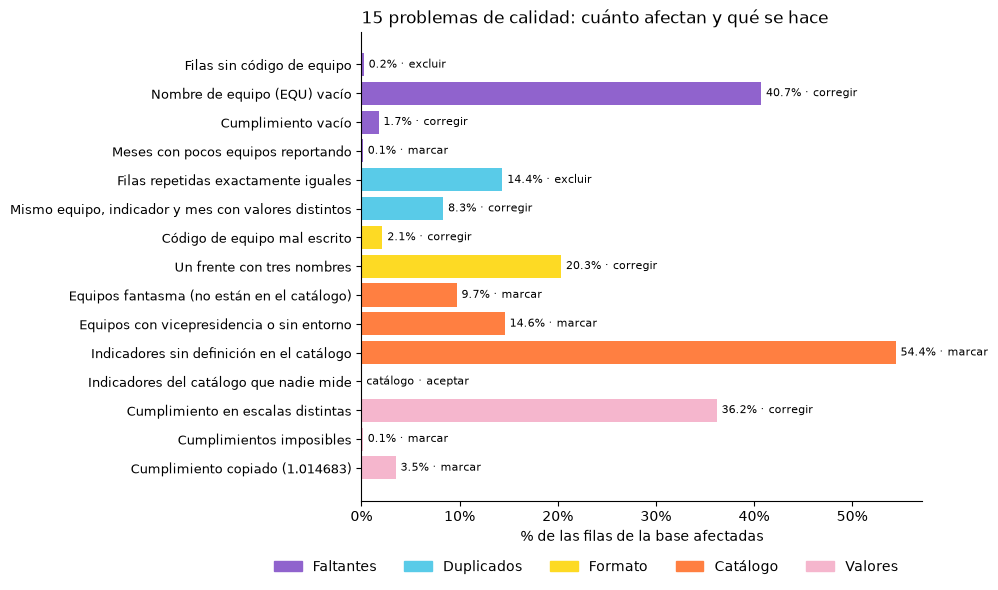

In [7]:
registro = pd.DataFrame(registro)

orden = registro.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(orden)), orden["filas_afectadas"] / TOTAL, color=orden["categoria"].map(CATEGORIAS))
for i, fila in enumerate(orden.itertuples()):
    texto = f"{fila.filas_afectadas / TOTAL:.1%}" if fila.filas_afectadas else "catálogo"
    ax.text(fila.filas_afectadas / TOTAL + 0.005, i, f"{texto} · {fila.tratamiento.split(' ')[0]}", va="center", fontsize=8)
ax.set_yticks(range(len(orden)), orden["problema"], fontsize=9)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_xlabel("% de las filas de la base afectadas")
ax.legend(handles=[Patch(color=c, label=k) for k, c in CATEGORIAS.items()], frameon=False, ncol=5,
          loc="upper center", bbox_to_anchor=(0.4, -0.1))
ax.set_title(f"{len(registro)} problemas de calidad: cuánto afectan y qué se hace", loc="left")
limpiar_ejes(ax)
plt.tight_layout()
plt.show()


In [8]:
# Registro completo con la categoría como etiqueta de color
tabla = registro[["categoria", "problema", "evidencia", "impacto", "tratamiento"]]
display(
    tabla.style.hide(axis="index")
    .map(lambda c: f"background-color: {CATEGORIAS[c]}; color: {'white' if c == 'Faltantes' else '#2a2625'}; font-weight: bold",
         subset=["categoria"])
    .set_properties(**{"text-align": "left", "vertical-align": "top"})
)


categoria,problema,evidencia,impacto,tratamiento
Faltantes,Filas sin código de equipo,36 filas (0.2%),La medición no se puede asignar a ningún equipo ni entorno.,excluir
Faltantes,Nombre de equipo (EQU) vacío,"6,185 filas (40.7%)",Reportes sin nombre legible; el código sí está.,corregir (tomar el nombre del catálogo o de otras filas del mismo código)
Faltantes,Cumplimiento vacío,265 filas (1.7%); 59 se pueden recalcular con Resultado y Meta,Mediciones que no cuentan en el desempeño del equipo.,corregir las recuperables; excluir el resto
Faltantes,Meses con pocos equipos reportando,202510: 20 equipos (normal: 64),El promedio del mes representa a pocos equipos.,marcar (mostrar cuántos equipos hay detrás de cada cifra)
Duplicados,Filas repetidas exactamente iguales,"2,182 filas (14.4%); 56% están en 202502",Cuentan doble a algunos equipos y meses e inflan promedios.,excluir (se deja una)
Duplicados,"Mismo equipo, indicador y mes con valores distintos","1,265 filas; 962 son respuestas individuales de encuesta (Percepción/Adopción 202502)",No hay un único valor oficial del mes y los equipos con más respuestas pesan más.,"corregir (promedio por equipo, indicador y mes)"
Formato,Código de equipo mal escrito,325 filas (2.1%); minúsculas o dígitos de menos; 146 escrituras para 89 equipos,Un mismo equipo parece varios equipos distintos.,corregir (mayúsculas y 5 dígitos)
Formato,Un frente con tres nombres,"3,089 filas (20.3%); Talento + Agilidad (2023-24), Modelos… (2025), Modeos… (2026)",El histórico del frente se ve cortado en tres frentes distintos.,"corregir (homologar a 'Modelos de trabajo y Agilidad', también en el catálogo)"
Catálogo,Equipos fantasma (no están en el catálogo),"1,473 filas (9.7%) de 26 equipos; 8 siguen activos en 2026",No se pueden agrupar por entorno.,marcar como 'Sin entorno' y reportar los activos al dueño del catálogo
Catálogo,Equipos con vicepresidencia o sin entorno,"2,218 filas (14.6%) de 13 equipos",Mezclarlos con entornos compara niveles distintos de la organización.,marcar como 'Sin entorno' conservando la vicepresidencia


**Lectura:** los problemas que más filas afectan no son errores de digitación sino de **significado**: más de la mitad de las filas usan indicadores sin definición oficial y más de un tercio tiene el cumplimiento en otra escala. Ambos se deben resolver antes de comparar equipos. Los valores imposibles y copiados afectan pocas filas, pero distorsionan cualquier promedio si no se excluyen.
